## Heston Model Simulation

The Heston model describes the underlying price  $S_t$  and variance  $v_t$  using two stochastic differential equations (SDEs):


$dS_t = \mu S_t dt + \sqrt{v_t} S_t dW_t^S$



$dv_t = \kappa (\theta - v_t) dt + \sigma \sqrt{v_t} dW_t^v$

where:
- $S_t$ = Asset price
- $v_t$ = Variance process
- $\mu$  = Risk-free rate
- $ \kappa$  = Speed of mean reversion
- $ \theta$  = Long-term variance
- $\sigma$  = Volatility of volatility
- $\rho$  = Correlation between asset and variance



### 1.1 Simulate Heston Paths

We discretize the SDEs using Euler-Maruyama.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def heston_simulation(S0, v0, r, kappa, theta, sigma, rho, T, N, M):
    """
    Simulates paths for the Heston stochastic volatility model.

    Parameters:
    S0 : float  -> Initial stock price
    v0 : float  -> Initial variance
    r  : float  -> Risk-free rate
    kappa : float -> Mean reversion speed
    theta : float -> Long-term variance
    sigma : float -> Volatility of volatility
    rho : float  -> Correlation between Brownian motions
    T  : float  -> Time to maturity (years)
    N  : int    -> Number of time steps
    M  : int    -> Number of simulated paths

    Returns:
    S : ndarray -> Simulated asset prices
    v : ndarray -> Simulated variance
    """
    dt = T / N
    S = np.zeros((N + 1, M))
    v = np.zeros((N + 1, M))

    S[0] = S0
    v[0] = v0

    # Generate correlated Brownian motions
    W1 = np.random.randn(N, M) * np.sqrt(dt)
    W2 = np.random.randn(N, M) * np.sqrt(dt)
    Wv = rho * W1 + np.sqrt(1 - rho**2) * W2  # Correlated volatility noise

    for t in range(1, N + 1):
        v[t] = np.maximum(v[t - 1] + kappa * (theta - v[t - 1]) * dt + sigma * np.sqrt(v[t - 1]) * Wv[t - 1], 0)
        S[t] = S[t - 1] * np.exp((r - 0.5 * v[t]) * dt + np.sqrt(v[t]) * W1[t - 1])
    
    return S, v


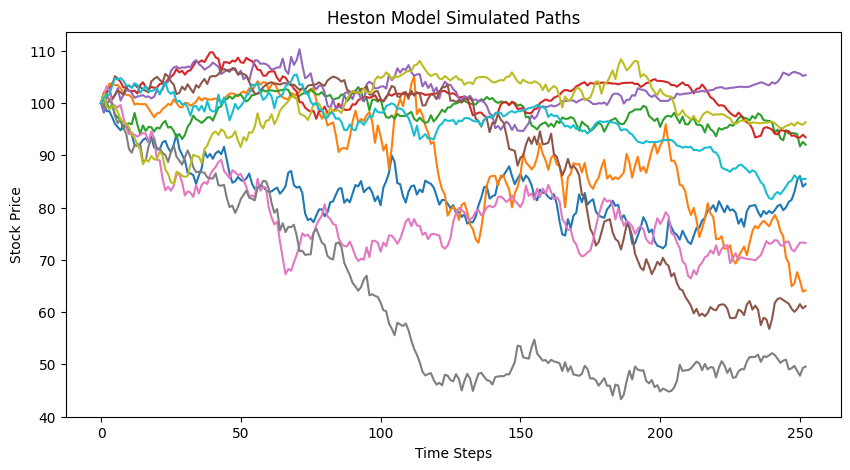

In [12]:
# Example Usage
S0, v0, r, kappa, theta, sigma, rho, T, N, M = 100, 0.04, 0.02, 2.0, 0.04, 0.5, -0.5, 1.0, 252, 10000
S, v = heston_simulation(S0, v0, r, kappa, theta, sigma, rho, T, N, M)

# Plot one path
plt.figure(figsize=(10, 5))
plt.plot(S[:, :10]) 
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.title('Heston Model Simulated Paths')
plt.show()

## 2. Heston Monte Carlo Option Pricing

Now that we have asset paths, we compute the expected discounted payoff to price a European Call option.


$C = e^{-rT} \mathbb{E} [\max(S_T - K, 0)]$


In [13]:
def heston_monte_carlo(S0, v0, r, kappa, theta, sigma, rho, T, K, N, M):
    """
    Monte Carlo pricing of a European Call option under the Heston model.
    """
    S, _ = heston_simulation(S0, v0, r, kappa, theta, sigma, rho, T, N, M)
    payoff = np.maximum(S[-1] - K, 0)  # Compute call option payoff
    
    return np.exp(-r * T) * np.mean(payoff)


In [14]:
# Example Usage
K = 100  # Strike price
option_price = heston_monte_carlo(S0, v0, r, kappa, theta, sigma, rho, T, K, N, M)
print(f"Heston Model Call Option Price: {option_price:.4f}")

Heston Model Call Option Price: 2.4843


## 3. Calibrating Heston Parameters to Market Data

We calibrate  $\kappa$, $\theta$, $\sigma$, $\rho$, $v_0$  by minimizing the Mean Squared Error (MSE) between market and model prices.

In [15]:
from scipy.optimize import minimize

# Fake market prices (Replace with real data)
market_prices = np.array([10.5, 8.9, 7.3, 6.0, 4.8])
strikes = np.array([95, 100, 105, 110, 115])
T = 1.0  # Assume 1-year expiry

def objective(params):
    kappa, theta, sigma, rho, v0 = params
    model_prices = np.array([heston_monte_carlo(S0, v0, r, kappa, theta, sigma, rho, T, K, N, M) for K in strikes])
    return np.sum((market_prices - model_prices) ** 2)  # Minimize squared error

# Initial parameter guess
initial_guess = [2.0, 0.04, 0.5, -0.5, 0.04]
bounds = [(0.01, 5), (0.01, 1), (0.01, 2), (-1, 1), (0.01, 1)]

# Optimize Heston parameters
result = minimize(objective, initial_guess, bounds=bounds, method='L-BFGS-B')
kappa, theta, sigma, rho, v0 = result.x
print(f"Optimized Heston Parameters: κ={kappa:.4f}, θ={theta:.4f}, σ={sigma:.4f}, ρ={rho:.4f}, v0={v0:.4f}")

Optimized Heston Parameters: κ=2.0000, θ=0.0400, σ=0.5000, ρ=-0.5000, v0=0.0400


## 4. Compare Black-Scholes to this results...

To be continue...